In [1]:
import json
import numpy as np
import h5py
import xgboost as xgb
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Shared config ────────────────────────────────────────────────────────────
SPLITS_PATH = "/code/jjiang23/pathml/aim2_balanceV2/data/splits.json"
PHASE_NAMES = ["Phase1", "Phase2", "Phase3", "Phase4"]

LABEL_MAP = {
    b"Phase1": 0,
    b"Phase2": 1,
    b"Phase3": 2,
    b"Phase4": 3,
    b"nonphase": 4,   # excluded
}

XGB_PARAMS = dict(
    objective        = "multi:softprob",
    num_class        = 4,
    n_estimators     = 400,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    use_label_encoder= False,
    eval_metric      = "mlogloss",
    tree_method      = "hist",
    verbosity        = 0,
    n_jobs           = -1,
    random_state     = 42,
)

# ── Experiment configurations ────────────────────────────────────────────────
# joint_indices=None  → use all joints
# For MediaPipe (world_mp_cropped_iou): h5 shape (T, 1, J, >=3), J=33
#   joints 0-10  = face
#   joints 11-22 = upper body (shoulders → wrists)
#   joints 23-32 = lower body (hips → feet)
# For MotionBert (motionBert_cropped_iou): h5 shape (T, J, D), J=17 (H3.6M)
#   joints 0-6   = lower body (pelvis, hips, knees, ankles)
#   joints 7-16  = upper body (spine, thorax, neck, head, shoulders, elbows, wrists)

EXPERIMENTS = [
    {
        "name":          "MPW Full (33J)",
        "h5_key":        "world_mp_cropped_iou",
        "joint_indices": None,
    },
    {
        "name":          "MPW Bottom Half (10J)",
        "h5_key":        "world_mp_cropped_iou",
        "joint_indices": list(range(23, 33)),   # hips → feet
    },
    {
        "name":          "MPW Top Half (12J)",
        "h5_key":        "world_mp_cropped_iou",
        "joint_indices": list(range(11, 23)),   # shoulders → wrists
    },
    {
        "name":          "MotionBert Full (17J)",
        "h5_key":        "motionBert_cropped_iou",
        "joint_indices": None,
    },
    {
        "name":          "MotionBert Bottom Half (7J)",
        "h5_key":        "motionBert_cropped_iou",
        "joint_indices": list(range(0, 7)),     # pelvis, hips, knees, ankles
    },
    {
        "name":          "MotionBert Top Half (10J)",
        "h5_key":        "motionBert_cropped_iou",
        "joint_indices": list(range(7, 17)),    # spine → wrists
    },
]

with open(SPLITS_PATH) as f:
    splits = json.load(f)

print(f"Folds: {list(splits.keys())}")
print(f"Experiments: {[e['name'] for e in EXPERIMENTS]}")

Folds: ['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4']
Experiments: ['MPW Full (33J)', 'MPW Bottom Half (10J)', 'MPW Top Half (12J)', 'MotionBert Full (17J)', 'MotionBert Bottom Half (7J)', 'MotionBert Top Half (10J)']


In [3]:
# ── Data loaders ─────────────────────────────────────────────────────────────

def load_phase_frames(h5_paths, h5_key, joint_indices=None):
    """
    Load per-frame features (phase frames only, label 0-3) from h5 files.
    Returns:
        X: (N, J*3) float32
        y: (N,) int  — phase label 0-3
    """
    Xs, ys = [], []
    for path in h5_paths:
        try:
            with h5py.File(path, 'r') as f:
                if h5_key not in f:
                    continue
                raw = f[h5_key][:]
                if raw.ndim == 4:
                    kp = raw[:, 0, :, :3].astype(np.float32)
                else:
                    kp = raw[:, :, :3].astype(np.float32)
                raw_labels = f['camera_poses_labels'][:]
        except Exception as e:
            print(f"  Skipping {path}: {e}")
            continue

        labels = np.array([LABEL_MAP[lbl] for lbl in raw_labels], dtype=np.int32)
        kp     = np.nan_to_num(kp)
        if joint_indices is not None:
            kp = kp[:, joint_indices, :]
        mask = labels < 4
        if mask.sum() == 0:
            continue
        T, J, D = kp[mask].shape
        Xs.append(kp[mask].reshape(T, J * D))
        ys.append(labels[mask])

    if not Xs:
        return np.empty((0, 0), dtype=np.float32), np.empty((0,), dtype=np.int32)
    return np.concatenate(Xs, axis=0), np.concatenate(ys, axis=0)


def load_phase_frames_with_segments(h5_paths, h5_key, joint_indices=None):
    """
    Same as load_phase_frames but also returns segment groupings.
    A segment = contiguous run of the same phase label within one video.
    """
    Xs, y_frames, seg_ids_all, seg_true = [], [], [], []
    seg_counter = 0

    for path in h5_paths:
        try:
            with h5py.File(path, 'r') as f:
                if h5_key not in f:
                    continue
                raw = f[h5_key][:]
                if raw.ndim == 4:
                    kp = raw[:, 0, :, :3].astype(np.float32)
                else:
                    kp = raw[:, :, :3].astype(np.float32)
                raw_labels = f['camera_poses_labels'][:]
        except Exception:
            continue

        labels = np.array([LABEL_MAP[lbl] for lbl in raw_labels], dtype=np.int32)
        kp     = np.nan_to_num(kp)
        if joint_indices is not None:
            kp = kp[:, joint_indices, :]

        mask = labels < 4
        if mask.sum() == 0:
            continue
        kp_ph  = kp[mask]
        lbl_ph = labels[mask]
        T, J, D = kp_ph.shape

        changes    = np.where(np.diff(lbl_ph) != 0)[0] + 1
        boundaries = np.concatenate([[0], changes, [T]])

        seg_ids_video = np.empty(T, dtype=np.int64)
        for start, end in zip(boundaries[:-1], boundaries[1:]):
            seg_ids_video[start:end] = seg_counter
            seg_true.append(lbl_ph[start])
            seg_counter += 1

        Xs.append(kp_ph.reshape(T, J * D))
        y_frames.append(lbl_ph)
        seg_ids_all.append(seg_ids_video)

    if not Xs:
        return (np.empty((0, 0), dtype=np.float32), np.empty((0,), dtype=np.int32),
                np.empty((0,), dtype=np.int64),      np.empty((0,), dtype=np.int32))
    return (np.concatenate(Xs),
            np.concatenate(y_frames),
            np.concatenate(seg_ids_all),
            np.array(seg_true, dtype=np.int32))


def majority_vote(y_pred, seg_ids, seg_true):
    """Majority-vote predictions per segment. Returns (y_pred_seg, y_true_seg, macro_f1)."""
    unique_segs = np.unique(seg_ids)
    y_pred_seg  = np.array([
        np.bincount(y_pred[seg_ids == s]).argmax()
        for s in unique_segs
    ])
    y_true_seg = np.array([seg_true[i] for i, _ in enumerate(unique_segs)])
    seg_f1 = f1_score(y_true_seg, y_pred_seg, average='macro', zero_division=0)
    return y_pred_seg, y_true_seg, seg_f1


# Sanity check
for exp in EXPERIMENTS:
    X, y = load_phase_frames(splits['fold_0']['train'][:2], exp['h5_key'], exp['joint_indices'])
    print(f"{exp['name']:<30} X={X.shape}  dist={np.bincount(y) if len(y) else 'empty'}")

MPW Full (33J)                 X=(1803, 99)  dist=[600 601 602]
MPW Bottom Half (10J)          X=(1803, 30)  dist=[600 601 602]
MPW Top Half (12J)             X=(1803, 36)  dist=[600 601 602]
MotionBert Full (17J)          X=(1803, 51)  dist=[600 601 602]
MotionBert Bottom Half (7J)    X=(1803, 21)  dist=[600 601 602]
MotionBert Top Half (10J)      X=(1803, 30)  dist=[600 601 602]


In [4]:
# ── Run all experiments × all folds ─────────────────────────────────────────
all_results = {}

for exp in EXPERIMENTS:
    exp_name = exp['name']
    print(f"\n{'#'*70}")
    print(f"  EXPERIMENT: {exp_name}")
    print(f"{'#'*70}")

    fold_results = []

    for fold_name, fold_data in splits.items():
        print(f"\n  {'='*56}")
        print(f"  {fold_name}")
        print(f"  {'='*56}")

        X_train, y_train = load_phase_frames(
            fold_data['train'], exp['h5_key'], exp['joint_indices'])
        X_val, y_val, seg_ids_val, seg_true_val = load_phase_frames_with_segments(
            fold_data['val'], exp['h5_key'], exp['joint_indices'])

        n_segs = len(np.unique(seg_ids_val)) if len(seg_ids_val) else 0
        print(f"  train: {X_train.shape[0]:,} frames  "
              f"val: {X_val.shape[0]:,} frames ({n_segs} segments)  "
              f"features: {X_train.shape[1] if len(X_train) else 0}")

        if X_train.shape[0] == 0 or X_val.shape[0] == 0:
            print("  Skipping — empty split")
            continue

        sample_weights = compute_sample_weight('balanced', y_train)

        clf = xgb.XGBClassifier(**XGB_PARAMS)
        clf.fit(X_train, y_train,
                sample_weight=sample_weights,
                eval_set=[(X_val, y_val)],
                verbose=False)

        y_pred_frame = clf.predict(X_val)
        frame_f1     = f1_score(y_val, y_pred_frame, average='macro', zero_division=0)

        y_pred_seg, y_true_seg, seg_f1 = majority_vote(
            y_pred_frame, seg_ids_val, seg_true_val)

        print(f"  Frame macro-F1:   {frame_f1:.4f}")
        print(f"  Segment macro-F1: {seg_f1:.4f}  ({n_segs} segments)")
        print(classification_report(y_true_seg, y_pred_seg, target_names=PHASE_NAMES, digits=3))

        fold_results.append({
            "fold":       fold_name,
            "frame_f1":   frame_f1,
            "seg_f1":     seg_f1,
            "y_val":      y_val,
            "y_pred":     y_pred_frame,
            "cm_frame":   confusion_matrix(y_val,      y_pred_frame),
            "y_true_seg": y_true_seg,
            "y_pred_seg": y_pred_seg,
            "cm_seg":     confusion_matrix(y_true_seg, y_pred_seg),
        })

    all_results[exp_name] = fold_results


######################################################################
  EXPERIMENT: MPW Full (33J)
######################################################################

  fold_0


  train: 84,773 frames  val: 19,972 frames (73 segments)  features: 99


  Frame macro-F1:   0.6856
  Segment macro-F1: 0.6748  (73 segments)
              precision    recall  f1-score   support

      Phase1      0.600     0.750     0.667        20
      Phase2      0.600     0.600     0.600        20
      Phase3      0.737     0.737     0.737        19
      Phase4      0.889     0.571     0.696        14

    accuracy                          0.671        73
   macro avg      0.706     0.665     0.675        73
weighted avg      0.691     0.671     0.672        73


  fold_1


  train: 83,325 frames  val: 21,420 frames (77 segments)  features: 99


  Frame macro-F1:   0.7745
  Segment macro-F1: 0.7939  (77 segments)
              precision    recall  f1-score   support

      Phase1      0.692     0.857     0.766        21
      Phase2      0.800     0.600     0.686        20
      Phase3      0.857     0.857     0.857        21
      Phase4      0.867     0.867     0.867        15

    accuracy                          0.792        77
   macro avg      0.804     0.795     0.794        77
weighted avg      0.799     0.792     0.790        77


  fold_2


...

  Frame macro-F1:   0.3918
  Segment macro-F1: 0.3838  (77 segments)
              precision    recall  f1-score   support

      Phase1      0.342     0.619     0.441        21
      Phase2      0.333     0.238     0.278        21
      Phase3      0.467     0.350     0.400        20
      Phase4      0.556     0.333     0.417        15

    accuracy                          0.390        77
   macro avg      0.424     0.385     0.384        77
weighted avg      0.414     0.390     0.381        77


  fold_3


  train: 84,375 frames  val: 20,370 frames (74 segments)  features: 30


  Frame macro-F1:   0.3275
  Segment macro-F1: 0.3065  (74 segments)
              precision    recall  f1-score   support

      Phase1      0.324     0.550     0.407        20
      Phase2      0.333     0.200     0.250        20
      Phase3      0.300     0.316     0.308        19
      Phase4      0.375     0.200     0.261        15

    accuracy                          0.324        74
   macro avg      0.333     0.316     0.306        74
weighted avg      0.331     0.324     0.310        74


  fold_4


  train: 84,124 frames  val: 20,621 frames (75 segments)  features: 30


  Frame macro-F1:   0.2846
  Segment macro-F1: 0.2818  (75 segments)
              precision    recall  f1-score   support

      Phase1      0.278     0.238     0.256        21
      Phase2      0.250     0.250     0.250        20
      Phase3      0.312     0.250     0.278        20
      Phase4      0.286     0.429     0.343        14

    accuracy                          0.280        75
   macro avg      0.281     0.292     0.282        75
weighted avg      0.281     0.280     0.277        75



                             Frame F1 Mean  Frame F1 Std  Segment F1 Mean  Segment F1 Std  N Folds
Experiment                                                                                        
MPW Full (33J)                      0.7107        0.0514           0.7238          0.0749        5
MPW Bottom Half (10J)               0.7187        0.0378           0.7402          0.0500        5
MPW Top Half (12J)                  0.3261        0.0500           0.3211          0.0520        5
MotionBert Full (17J)               0.6428        0.0580           0.6303          0.0431        5
MotionBert Bottom Half (7J)         0.6500        0.0572           0.6439          0.0486        5
MotionBert Top Half (10J)           0.3278        0.0421           0.3153          0.0523        5


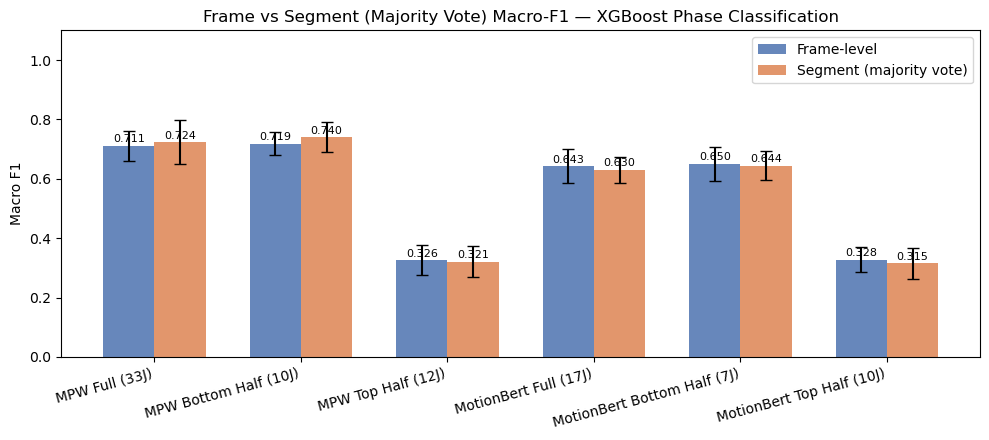

In [5]:
# ── Cross-experiment macro-F1 summary ────────────────────────────────────────
summary_rows = []
for exp_name, fold_results in all_results.items():
    if not fold_results:
        continue
    frame_f1s = [r['frame_f1'] for r in fold_results]
    seg_f1s   = [r['seg_f1']   for r in fold_results]
    summary_rows.append({
        'Experiment':      exp_name,
        'Frame F1 Mean':   np.mean(frame_f1s),
        'Frame F1 Std':    np.std(frame_f1s),
        'Segment F1 Mean': np.mean(seg_f1s),
        'Segment F1 Std':  np.std(seg_f1s),
        'N Folds':         len(frame_f1s),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Experiment')
print(df_summary.to_string(float_format=lambda x: f'{x:.4f}'))

fig, ax = plt.subplots(figsize=(10, 4.5))
x, w   = np.arange(len(df_summary)), 0.35

bars_f = ax.bar(x - w/2, df_summary['Frame F1 Mean'],   w,
                yerr=df_summary['Frame F1 Std'],   capsize=4,
                label='Frame-level', color='#4C72B0', alpha=0.85)
bars_s = ax.bar(x + w/2, df_summary['Segment F1 Mean'], w,
                yerr=df_summary['Segment F1 Std'], capsize=4,
                label='Segment (majority vote)', color='#DD8452', alpha=0.85)

for bar in [*bars_f, *bars_s]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_summary.index, rotation=15, ha='right')
ax.set_ylabel('Macro F1')
ax.set_title('Frame vs Segment (Majority Vote) Macro-F1 — XGBoost Phase Classification')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

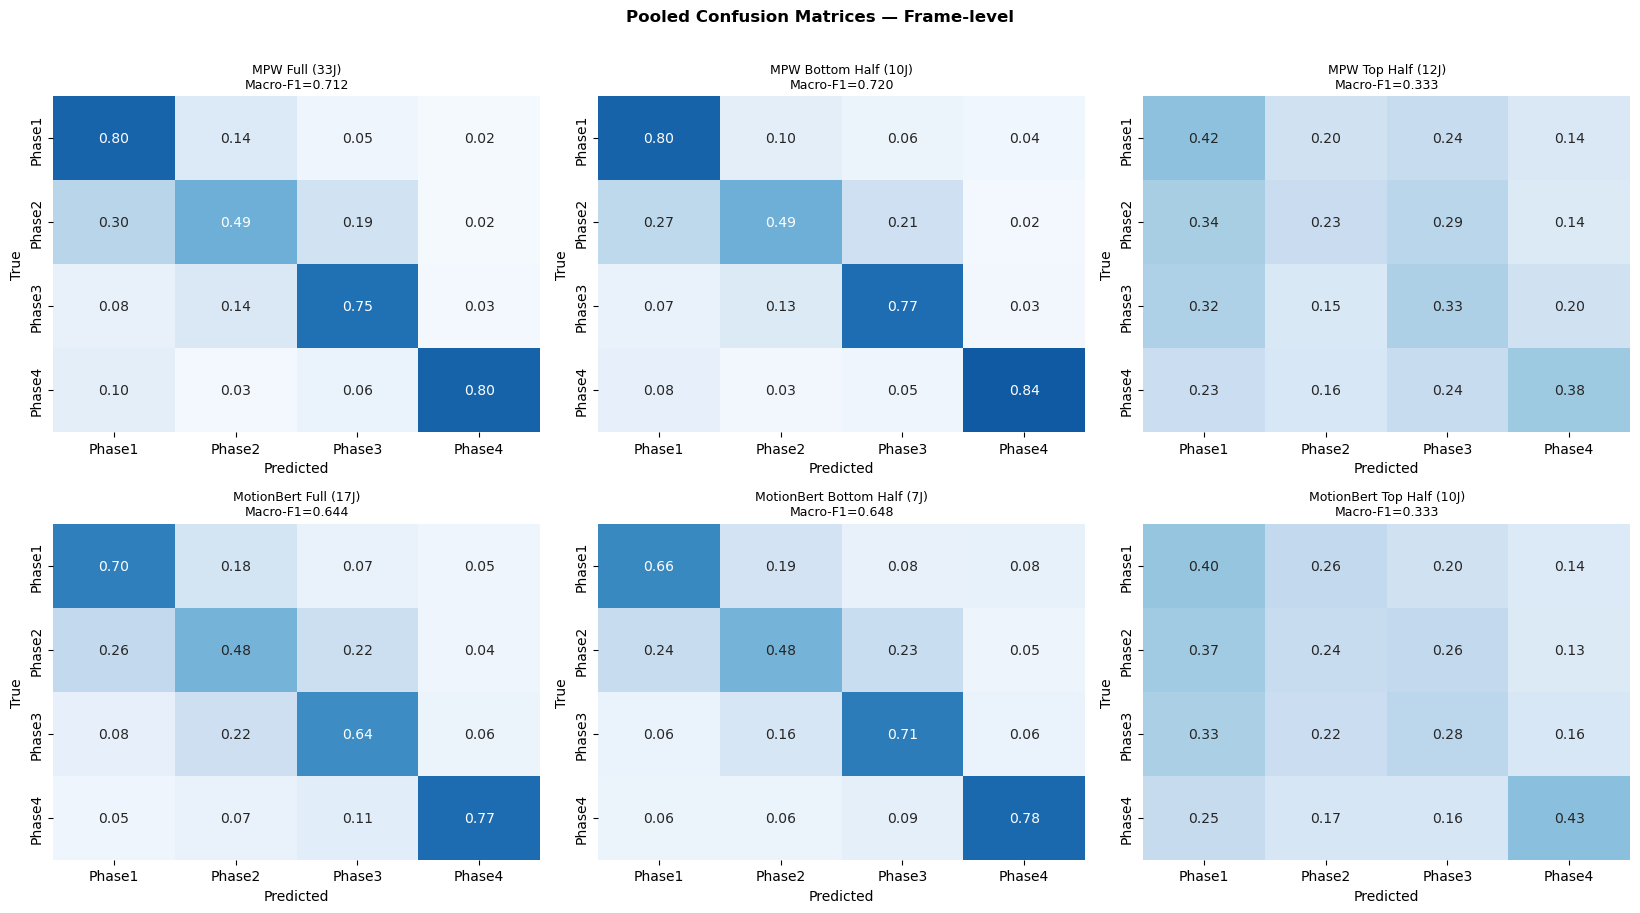

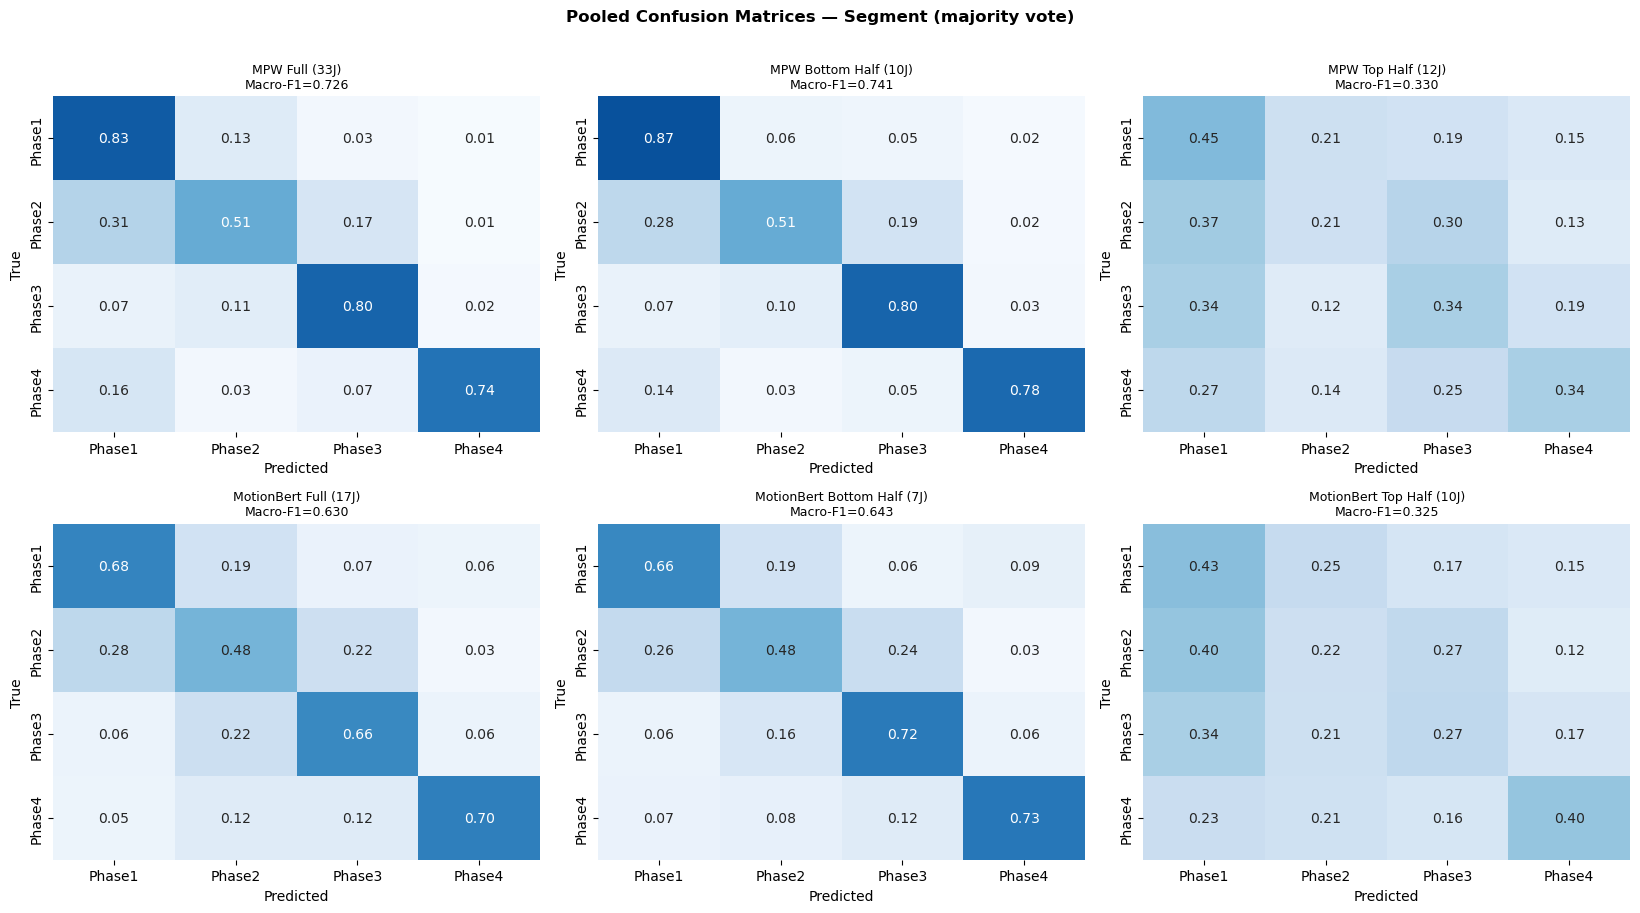

In [6]:
# ── Pooled confusion matrices — frame and segment level ───────────────────────
n_exp = len(all_results)
ncols = min(n_exp, 3)
nrows = (n_exp + ncols - 1) // ncols

for y_true_key, y_pred_key, title_suffix in [
    ('y_val',     'y_pred',    'Frame-level'),
    ('y_true_seg','y_pred_seg', 'Segment (majority vote)'),
]:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4.5 * nrows))
    axes = np.array(axes).flatten()

    for ax, (exp_name, fold_results) in zip(axes, all_results.items()):
        if not fold_results:
            ax.set_visible(False)
            continue
        y_true_all = np.concatenate([r[y_true_key] for r in fold_results])
        y_pred_all = np.concatenate([r[y_pred_key] for r in fold_results])
        cm      = confusion_matrix(y_true_all, y_pred_all)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        macro_f1 = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)

        sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                    xticklabels=PHASE_NAMES, yticklabels=PHASE_NAMES,
                    cmap='Blues', vmin=0, vmax=1, cbar=False)
        ax.set_title(f'{exp_name}\nMacro-F1={macro_f1:.3f}', fontsize=9)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

    for ax in axes[n_exp:]:
        ax.set_visible(False)

    plt.suptitle(f'Pooled Confusion Matrices — {title_suffix}', y=1.01, fontweight='bold')
    plt.tight_layout()
    plt.show()

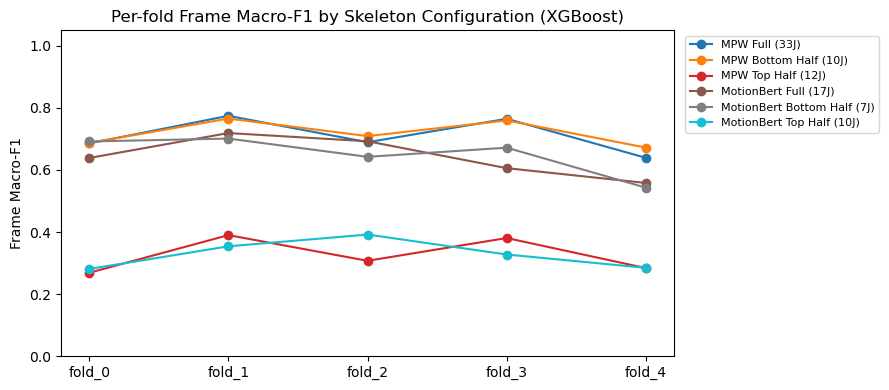

In [7]:
# ── Per-fold macro-F1 line plot ───────────────────────────────────────────────
fold_names = list(splits.keys())
fig, ax    = plt.subplots(figsize=(9, 4))
colors     = plt.cm.tab10(np.linspace(0, 0.9, len(all_results)))

for color, (exp_name, fold_results) in zip(colors, all_results.items()):
    if not fold_results:
        continue
    fold_f1s = {r['fold']: r['frame_f1'] for r in fold_results}
    ys = [fold_f1s.get(fn, np.nan) for fn in fold_names]
    ax.plot(fold_names, ys, marker='o', label=exp_name, color=color)

ax.set_ylabel('Frame Macro-F1')
ax.set_title('Per-fold Frame Macro-F1 by Skeleton Configuration (XGBoost)')
ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()